<a href="https://colab.research.google.com/github/furalmiqbadi/PembelajaranMesin_01_AbdulGhofurAlmiqbadi/blob/main/JS04/JS04_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Persiapan

In [23]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
# Mengimpor dataset
dataset = pd.read_csv('/content/Posisi_gaji.csv')

# iloc[:, 1:2] artinya: Ambil semua baris (:), dan kolom ke-1 sampai sebelum ke-2 (hanya kolom ke-1).
# Kita pakai 1:2 (bukan 1) agar hasilnya tetap berbentuk 2D Array (kolom), yang diwajibkan oleh SVR.
X = dataset.iloc[:, 1:2].values

# iloc[:, 2] artinya: Ambil semua baris (:), dan kolom ke-2 (Target: Gaji).
# Hasilnya 1D Array (baris), yang tidak masalah untuk variabel target (y).
y = dataset.iloc[:, 2].values

# Feature Scaling (Penskalaan Fitur)

In [25]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

# .reshape(-1, 1) digunakan untuk mengubah array 1D menjadi 2D (satu kolom)
# karena StandardScaler hanya menerima input berbentuk 2D.
# PENTING: SVR menghitung "jarak" antar data. Jika skala X (1-10) dan Y (40000-100000)
# sangat berbeda, SVR akan bingung. Scaling membuat semuanya berada di skala yang setara (sekitar -1 sampai 1).
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))


# Fitting Model SVR

In [26]:
from sklearn.svm import SVR

# kernel='rbf' memungkinkan model membuat garis prediksi yang melengkung (non-linier)
# untuk menyesuaikan pola data yang kompleks, bukan garis lurus kaku.
regressor = SVR(kernel='rbf')
regressor.fit(X, y) # Proses "belajar" model dari data

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

# Visualisasi Hasil SVR

/tmp/ipykernel_2023/552836539.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


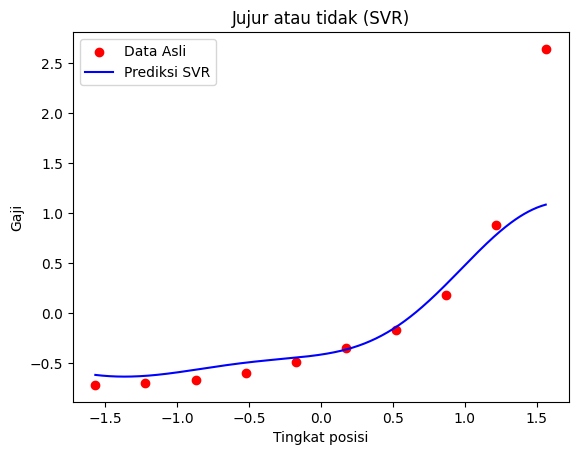

In [27]:
# Membuat titik-titik X yang sangat rapat (step 0.01) agar garis prediksi terlihat halus dan mulus,
# bukan berupa garis patah-patah yang menghubungkan titik data asli.
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)

plt.scatter(X, y, color='red', label='Data Asli')
plt.plot(X_grid, regressor.predict(X_grid), color='blue', label='Prediksi SVR')
plt.title('Jujur atau tidak (SVR)')
plt.xlabel('Tingkat posisi')
plt.ylabel('Gaji')
plt.legend()
plt.show()


# Prediksi Hasil & Menampilkan

In [28]:
# Kita ingin memprediksi gaji untuk tingkat posisi 6.5
tingkat_posisi_prediksi = np.array([[6.5]]) # Harus bentuk 2D array

# 1. Skala-kan dulu input ini agar "dimengerti" oleh model yang sudah terbiasa dengan data terskala
tingkat_posisi_prediksi_scaled = sc_X.transform(tingkat_posisi_prediksi)

# 2. Lakukan prediksi (hasilnya masih dalam bentuk skala terskala, misal: 0.85)
gaji_prediksi_scaled = regressor.predict(tingkat_posisi_prediksi_scaled)

# 3. KEMBALIKAN ke skala asli (dolar) agar bisa dibaca manusia (misal: 170370)
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi_scaled.reshape(-1, 1))

print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [170370.0204065]


# Evaluasi Model SVR

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Di kode ini, y_actual dan y_pred masih dalam bentuk "terskala" (scaled).
# Jadi nilai MAE/MSE-nya kecil (0.22), karena ini adalah error dalam satuan skala standar, BUKAN dalam dolar.
# Untuk mendapatkan error dalam dolar, kita seharusnya melakukan inverse_transform pada y_pred terlebih dahulu.
y_actual = y
y_pred = regressor.predict(X)

mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("MAE (Scaled):", mae)
print("MSE (Scaled):", mse)
print("RMSE (Scaled):", rmse)
print("R-squared:", r2) # R-squared tidak terpengaruh oleh scaling, jadi nilainya tetap valid (0.75 = cukup baik)

MAE (Scaled): 0.22299274095734414
MSE (Scaled): 0.24839989293792014
RMSE (Scaled): 0.4983973243687411
R-squared: 0.7516001070620798
